In [ ]:
import pandas  as  pd
import  numpy  as  np
import matplotlib.pyplot  as  plt
import   seaborn  as  sns
import warnings
warnings.filterwarnings("ignore")
import re
import unicodedata
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from xgboost import XGBClassifier


Here’s what happens in this notebook, step by step:

First, it loads the food product data from a CSV into a pandas DataFrame. After that, it takes a quick look at the data to get a sense of what’s inside.

Next comes feature engineering. Columns related to ‘ingredients_hierarchy’ and ‘categories_hierarchy’ get combined into neat text fields. There’s a custom function at work here—one that cleans things up by removing language prefixes, standardizing how everything’s separated, and getting rid of duplicates. All these bits of ingredient and category info are then glued together in a new column called ‘final_text’.

Now, for the text cleaning part. The code runs a pretty thorough cleanup function on all this raw text. It lowercases everything, normalizes unicode, and strips out things like language prefixes, URLs, punctuation, and stray numbers. It squeezes out extra spaces and lemmatizes the words so they're in base form. When it's done, you get new columns: ‘clean_ingredients’, ‘clean_hierarchy’, ‘clean_category’, and ‘clean_product’. It then drops any rows that ended up empty after cleaning, and removes duplicates based on these columns and the ‘ecoscore_grade’ to keep the dataset tidy and reliable.

The project then adds some smart numerical features. It flags whether certain ingredients or product names are present, counts specific additives (both E-numbers and description keywords) in the ‘ingredients_text_en’ column, and calculates how long the cleaned ingredient and product descriptions are, word-wise. It also pulls out all the E-number additives from the ingredient list into a separate, streamlined column.

With the features ready, the data gets prepped for modeling. The code turns the ‘ecoscore_grade’ into ordered numerical labels using LabelEncoder, then splits the data into training and testing sets. For text features, it uses a ColumnTransformer that applies separate TfidfVectorizers to ‘clean_ingredients’, ‘clean_hierarchy’, ‘clean_category’, and ‘clean_product’, which converts the text into numbers that machine learning models can handle.

Now it’s modeling time. The main model is an XGBoost Classifier, known for handling these kinds of classification tasks really well. After training, the code checks how well it’s doing by looking at accuracy, a classification report (breaking down precision, recall, and f1-score per ‘ecoscore_grade’), and a confusion matrix that shows where the model’s getting things right or wrong, class by class.

For comparison, it trains a Multinomial Naive Bayes classifier on the same data. This one’s simpler and serves as a baseline, helping to highlight the difference in performance and giving context for the XGBoost results. Both models get evaluated on accuracy and a classification report to see how they stack up.

In [ ]:
df_row=pd.read_csv("FoodFacts.products.170k_May26.csv")
df_row.head()

,_id,product_name_en,ecoscore_grade,ingredients_text_en,categories,categories_hierarchy[0],categories_hierarchy[1],categories_hierarchy[2],categories_hierarchy[3],categories_hierarchy[4],...,packaging_hierarchy[43],packaging_hierarchy[44],packaging_hierarchy[45],packaging_hierarchy[46],packaging_hierarchy[47],packaging_hierarchy[48],packaging_hierarchy[49],packaging_hierarchy[50],packaging_hierarchy[51],packaging_hierarchy[52]
0,7896010000000.0,123,f,NaN,"Beverages and beverages preparations, Beverage...",en:beverages-and-beverages-preparations,en:plant-based-foods-and-beverages,en:beverages,en:plant-based-foods,en:beverage-preparations,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8410390000000.0,2022,e,NaN,"Dranken en drankbereidingen,Dranken,Alcoholisc...",en:beverages-and-beverages-preparations,en:beverages,en:alcoholic-beverages,en:wines,en:red-wines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8901060000000.0,5050,c,NaN,Biscuits,en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4004200000000.0,5.00017E+12,c,NaN,Green tapenades,en:spreads,en:salted-spreads,en:tapenades,en:green-tapenades,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5203060000000.0,5.20306E+12,d,dog,Chocolate Cookie,en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits-and-crackers,en:biscuits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_row["ingredients_text_en"].iloc[20
]

'Noodles: premium wheat flour, vegetable oil, salt (extra food salt, anti-caking agent E 536), gluten, premix stabilizer (stabilizers: E501i, E412, E452i), soy product (soy sauce powder, sugar, salt, yeast extract, fried onion). Broth-seasoning: broth base (chicken broth powder with vegetables, roasted red pepper, garlic, yeast extract, black pepper, flavoring, guar gum thickener), salt (extra food salt, anti-caking agent E 536), flavor and aroma enhancer ( E621), sugar, potato starch. Seasoning from dried vegetables: carrots, soy texture with chicken flavor (soy flour, soy sauce, sugar, glucose syrup, salt, flavoring), onion. Sauce: water, dry chicken extract, salt, sugar, vegetable oil, flavor and aroma enhancer (E621), preservatives (E211, E202), antioxidant (sodium isoascorbate).\\nThe product contains gluten, soy and traces of processed milk, fish, crustaceans and molluscs products.'

In [ ]:
df_row["product_name_en"].sample(30)

144971                                           NaN
125307                                           NaN
66232                                        Mustard
13476                                 Budweiser beer
38248           Frosted Pumpkin Pie Toaster Pastries
780                           100% Natural Black Tea
55379                       Lakeshore french mustard
15936                                  Carrot sticks
86350                            refresh organic tea
15942                                        Carrots
108510                                 Vin de shiraz
112803    Yellow cling sliced peaches in heavy syrup
127007                                           NaN
71750                 Organic Extra Virgin Olive Oil
152240                                           NaN
168926                                           NaN
90761              Sea Salt Dark Chocolate Mini Bars
145767                                           NaN
53027                                         

In [ ]:
df_row.columns

Index(['_id', 'product_name_en', 'ecoscore_grade', 'ingredients_text_en',
       'categories', 'categories_hierarchy[0]', 'categories_hierarchy[1]',
       'categories_hierarchy[2]', 'categories_hierarchy[3]',
       'categories_hierarchy[4]',
       ...
       'packaging_hierarchy[43]', 'packaging_hierarchy[44]',
       'packaging_hierarchy[45]', 'packaging_hierarchy[46]',
       'packaging_hierarchy[47]', 'packaging_hierarchy[48]',
       'packaging_hierarchy[49]', 'packaging_hierarchy[50]',
       'packaging_hierarchy[51]', 'packaging_hierarchy[52]'],
      dtype='object', length=509)

In [ ]:
for prefix in [
    'ingredients_hierarchy',
    'categories_hierarchy',
    'origins_hierarchy',
    'packaging_hierarchy'
]:
    cols = [c for c in df_row.columns if prefix in c]

    non_null = df_row[cols].notnull().sum().sum()

    print(prefix)
    print("columns:", len(cols))
    print("total non-null:", non_null)
    print()

ingredients_hierarchy
columns: 365
total non-null: 2184291

categories_hierarchy
columns: 42
total non-null: 1045255

origins_hierarchy
columns: 14
total non-null: 16557

packaging_hierarchy
columns: 53
total non-null: 43111



In [ ]:
df_row.shape

(171490, 509)

# step  1  create  columns  groups   

In [ ]:
ingredient_cols = [
    c for c in df_row.columns
    if 'ingredients_hierarchy' in c]

category_cols = [
    c for c in df_row.columns
    if 'categories_hierarchy' in c]

#  step  2  merging columns   function  

In [ ]:
def merge_hierarchy(row):

    values = []

    for item in row:

        if pd.notnull(item):

            # remove en:
            item = str(item).replace('en:', '')

            # replace hyphen with space
            item = item.replace('-', ' ')

            item = item.strip()

            if item:
                values.append(item)

    # remove duplicates while preserving order
    values = list(dict.fromkeys(values))

    return ' '.join(values)

# step 3  create  merged  smantic columns  

In [ ]:
df_row['ingredient_hierarchy_text'] = (
    df_row[ingredient_cols]
    .apply(merge_hierarchy, axis=1))

df_row['category_hierarchy_text'] = (
    df_row[category_cols]
    .apply(merge_hierarchy, axis=1))

In [ ]:
df_row['final_text'] = (
    df_row['ingredients_text_en'].fillna('') + ' ' +
    df_row['ingredient_hierarchy_text'].fillna('') + ' ' +
    df_row['category_hierarchy_text'].fillna(''))

In [ ]:
df_row[["final_text", "ingredient_hierarchy_text", "category_hierarchy_text"]].head()


,final_text,ingredient_hierarchy_text,category_hierarchy_text
0,sugar added sugar disaccharide whole milk dai...,sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...
1,beverages and beverages preparations beverag...,,beverages and beverages preparations beverages...
2,snacks sweet snacks biscuits and cakes biscuits,,snacks sweet snacks biscuits and cakes biscuits
3,spreads salted spreads tapenades green tapen...,,spreads salted spreads tapenades green tapenades
4,dog dog snacks sweet snacks biscuits and cakes...,dog,snacks sweet snacks biscuits and cakes biscuit...


In [ ]:
df_row['final_text'].iloc[0]

' sugar added sugar disaccharide whole milk dairy milk maltodextrin whey powder whey instant coffee coffee pt:composto lacteo com gordura vegetal sabor de leite cocoa powder plant cocoa pt:aromatizantes acidity regulator pt:espessante carboximetilcelulose sodica e antiumectante fosfato tricalcico pt:alergicos e500ii e500 pt:contem derivados de leite soya lactose beverages and beverages preparations plant based foods and beverages beverages plant based foods beverage preparations coffees instant beverages coffee drinks instant coffees coffee with milk with sugar'

In [ ]:
df_row.isnull().sum()

_id                               0
product_name_en               58008
ecoscore_grade                    0
ingredients_text_en           97165
categories                        5
                              ...  
packaging_hierarchy[51]      171489
packaging_hierarchy[52]      171489
ingredient_hierarchy_text         0
category_hierarchy_text           0
final_text                        0
Length: 512, dtype: int64

In [ ]:
df_exp = df_row[[
    'ecoscore_grade',
    'ingredients_text_en',
    'ingredient_hierarchy_text',
    'category_hierarchy_text','product_name_en',
    'final_text'
]].copy()

In [ ]:
df_exp["ecoscore_grade"].value_counts()

ecoscore_grade
d         49480
b         34570
c         25989
e         24354
a         23288
f         10102
a-plus     3707
Name: count, dtype: int64

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_final_text(text):

    if pd.isnull(text):
        return ""

    # lowercase
    text = text.lower()

    # unicode normalization
    text = unicodedata.normalize('NFKD', text)

    # remove language prefixes
    text = re.sub(r'\b[a-z]{2}:', ' ', text)

    # remove urls
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove weird device metadata
    text = re.sub(r'galaxy\s\w+.*', ' ', text)

    # replace hyphens with spaces
    text = text.replace('-', ' ')

    # remove punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # remove isolated numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # lemmatization
    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return ' '.join(words)

In [ ]:
df_exp['clean_text'] = (
    df_exp['final_text']
    .apply(clean_final_text)
)

In [ ]:
df_exp[['final_text', 'clean_text']].sample(5)

,final_text,clean_text
5433,"Enriched bleached wheat flour (bleached flour,...",enriched bleached wheat flour bleached flour m...
148444,ru:тесто фило ru:напиток кокосовый corn starc...,corn starch starch wheat flour cereal flour wh...
69121,"eggs (47%), sugar, brandy, bourbon vanilla, 6%...",egg sugar brandy bourbon vanilla alc egg sugar...
52292,"Isomalto-oligosaccharides (vegetable source), ...",isomalto oligosaccharide vegetable source citr...
148969,pt:farinhas sugar added sugar disaccharide pt...,farinhas sugar added sugar disaccharide cacau ...


In [ ]:
df_exp["clean_text"].iloc[0]

'sugar added sugar disaccharide whole milk dairy milk maltodextrin whey powder whey instant coffee coffee composto lacteo com gordura vegetal sabor de leite cocoa powder plant cocoa aromatizantes acidity regulator espessante carboximetilcelulose sodica e antiumectante fosfato tricalcico alergicos e500ii e500 contem derivados de leite soya lactose beverage and beverage preparation plant based food and beverage beverage plant based food beverage preparation coffee instant beverage coffee drink instant coffee coffee with milk with sugar'

In [ ]:
df_row.shape

(171490, 512)

In [ ]:
df_exp.shape

(171490, 7)

In [ ]:
df_exp.columns

Index(['ecoscore_grade', 'ingredients_text_en', 'ingredient_hierarchy_text',
       'category_hierarchy_text', 'product_name_en', 'final_text',
       'clean_text'],
      dtype='object')

In [ ]:
df_exp.isnull().sum()

ecoscore_grade                   0
ingredients_text_en          97165
ingredient_hierarchy_text        0
category_hierarchy_text          0
product_name_en              58008
final_text                       0
clean_text                       0
dtype: int64

In [ ]:
df_exp["clean_text"].duplicated().sum()

np.int64(81171)

In [ ]:
conflicts = (
    df_exp.groupby('clean_text')['ecoscore_grade']
    .nunique()
)

conflicts = conflicts[conflicts > 1]

print(len(conflicts))

2130


In [ ]:
duplicate_counts = (
    df_exp['clean_text']
    .value_counts()
)

print(duplicate_counts.head(20))

clean_text
breakfast spread sweet spread bee product farming product sweetener honey                                                                              2389
plant based food and beverage beverage hot beverage plant based beverage tea                                                                           1489
dairy fermented food fermented milk product cheese                                                                                                     1468
snack sweet snack biscuit and cake biscuit                                                                                                             1456
snack sweet snack confectionery candy                                                                                                                  1430
plant based food and beverage plant based food breakfast cereal and potato cereal and their product breakfast cereal                                   1094
plant based food and beverage plant based food fat ve

In [ ]:
df_exp.head()

,ecoscore_grade,ingredients_text_en,ingredient_hierarchy_text,category_hierarchy_text,product_name_en,final_text,clean_text
0,f,NaN,sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...,123,sugar added sugar disaccharide whole milk dai...,sugar added sugar disaccharide whole milk dair...
1,e,NaN,,beverages and beverages preparations beverages...,2022,beverages and beverages preparations beverag...,beverage and beverage preparation beverage alc...
2,c,NaN,,snacks sweet snacks biscuits and cakes biscuits,5050,snacks sweet snacks biscuits and cakes biscuits,snack sweet snack biscuit and cake biscuit
3,c,NaN,,spreads salted spreads tapenades green tapenades,5.00017E+12,spreads salted spreads tapenades green tapen...,spread salted spread tapenade green tapenade
4,d,dog,dog,snacks sweet snacks biscuits and cakes biscuit...,5.20306E+12,dog dog snacks sweet snacks biscuits and cakes...,dog dog snack sweet snack biscuit and cake bis...


In [ ]:
df_new = df_row[[
    'ecoscore_grade',
    'ingredients_text_en',
    'ingredient_hierarchy_text',
    'category_hierarchy_text',
    'product_name_en'
]].copy()

In [ ]:
df_new['clean_ingredients'] = (
    df_new['ingredients_text_en']
    .fillna('')
    .apply(clean_final_text)
)

df_new['clean_hierarchy'] = (
    df_new['ingredient_hierarchy_text']
    .fillna('')
    .apply(clean_final_text)
)

df_new['clean_category'] = (
    df_new['category_hierarchy_text']
    .fillna('')
    .apply(clean_final_text)
)

df_new['clean_product'] = (
    df_new['product_name_en']
    .fillna('')
    .apply(clean_final_text)
)

In [ ]:
df_new['clean_product'] = df_new['clean_product'].replace(
    r'^\w{1,6}e$',
    '',
    regex=True
)

In [ ]:
df_new = df_new[
    (
        df_new['clean_ingredients'].str.strip() != ''
    ) |
    (
        df_new['clean_hierarchy'].str.strip() != ''
    ) |
    (
        df_new['clean_product'].str.strip() != ''
    )
]

In [ ]:
df_new.head()

,ecoscore_grade,ingredients_text_en,ingredient_hierarchy_text,category_hierarchy_text,product_name_en,clean_ingredients,clean_hierarchy,clean_category,clean_product
0,f,NaN,sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...,123,,sugar added sugar disaccharide whole milk dair...,beverage and beverage preparation plant based ...,
4,d,dog,dog,snacks sweet snacks biscuits and cakes biscuit...,5.20306E+12,dog,dog,snack sweet snack biscuit and cake biscuit and...,
6,a,"GREEN ASPARAGUS (56%), Water. Salt, Acidity Re...",green asparagus vegetable shoot vegetable aspa...,plant based foods and beverages plant based fo...,Asparagus Spears,green asparagus water salt acidity regulator s...,green asparagus vegetable shoot vegetable aspa...,plant based food and beverage plant based food...,asparagus spear
7,a-plus,"Single cream (58%), Pasteurised Egg Yolk (12%)...",single cream dairy cream pasteurised egg yolk ...,dairies desserts dairy desserts creme brulee,Creme Brûlée,single cream pasteurised egg yolk sugar milk p...,single cream dairy cream pasteurised egg yolk ...,dairy dessert dairy dessert creme brulee,creme bru le e
8,a-plus,"Peach (50%), White Sugar, Brown Sugar, Concent...",peach fruit prunus species fruit white sugar a...,plant based foods and beverages plant based fo...,Peach Conserve,peach white sugar brown sugar concentrated lem...,peach fruit prunus specie fruit white sugar ad...,plant based food and beverage plant based food...,peach conserve


In [ ]:
duplicate_cols = [
    'ecoscore_grade',
    'clean_ingredients',
    'clean_hierarchy',
    'clean_category',
    'clean_product'
]

df_new = df_new.drop_duplicates(
    subset=duplicate_cols
)

In [ ]:
df_new.head()

,ecoscore_grade,ingredients_text_en,ingredient_hierarchy_text,category_hierarchy_text,product_name_en,clean_ingredients,clean_hierarchy,clean_category,clean_product
0,f,NaN,sugar added sugar disaccharide whole milk dair...,beverages and beverages preparations plant bas...,123,,sugar added sugar disaccharide whole milk dair...,beverage and beverage preparation plant based ...,
4,d,dog,dog,snacks sweet snacks biscuits and cakes biscuit...,5.20306E+12,dog,dog,snack sweet snack biscuit and cake biscuit and...,
6,a,"GREEN ASPARAGUS (56%), Water. Salt, Acidity Re...",green asparagus vegetable shoot vegetable aspa...,plant based foods and beverages plant based fo...,Asparagus Spears,green asparagus water salt acidity regulator s...,green asparagus vegetable shoot vegetable aspa...,plant based food and beverage plant based food...,asparagus spear
7,a-plus,"Single cream (58%), Pasteurised Egg Yolk (12%)...",single cream dairy cream pasteurised egg yolk ...,dairies desserts dairy desserts creme brulee,Creme Brûlée,single cream pasteurised egg yolk sugar milk p...,single cream dairy cream pasteurised egg yolk ...,dairy dessert dairy dessert creme brulee,creme bru le e
8,a-plus,"Peach (50%), White Sugar, Brown Sugar, Concent...",peach fruit prunus species fruit white sugar a...,plant based foods and beverages plant based fo...,Peach Conserve,peach white sugar brown sugar concentrated lem...,peach fruit prunus specie fruit white sugar ad...,plant based food and beverage plant based food...,peach conserve


In [ ]:
df_new[[
    'clean_ingredients',
    'clean_hierarchy',
    'clean_category',
    'clean_product'
]].sample(10)

,clean_ingredients,clean_hierarchy,clean_category,clean_product
41919,wheat flour wheat flour calcium carbonate iron...,wheat flour cereal flour wheat cereal flour wa...,plant based food and beverage plant based food...,gourmet burger mixed seed
16825,potato vegetable oil contains one or more of t...,potato vegetable root vegetable tuber vegetabl...,plant based food and beverage plant based food...,cheddar sour cream wavy potato chip
35886,organic fig organic rice flour organic sugar o...,fig fruit rice flour flour rice sugar added su...,snack sweet snack biscuit and cake biscuit,fig fruit filled organic cooky
7607,glucose fructose syrup sugar coffee liqueur gl...,glucose fructose syrup added sugar monosacchar...,dairy snack dessert sweet snack dairy dessert ...,balconi tiramisu
16487,,,meat and their product prepared meat sausage c...,cervelas
116888,sugar cocoa paste vegetable fat shea palm coco...,sugar added sugar disaccharide cocoa paste pla...,snack sweet snack cocoa and it product chocola...,
79001,,,beverage fermented food fermented drink tea ba...,pineapple chili hard kombucha
4208,bamboo shoot water citric acid,bamboo shoot vegetable shoot vegetable bamboo ...,plant based food and beverage plant based food...,always fresh sliced bamboo shoot
29998,,,dessert frozen food frozen dessert ice cream a...,denali moose track ice cream
132991,,water sugar added sugar disaccharide fructose ...,dessert frozen food frozen dessert ice pop,


In [ ]:
df_new = df_new.drop(columns=[
    'ingredients_text_en',
    'ingredient_hierarchy_text',
    'category_hierarchy_text',
    'product_name_en'
])

In [ ]:
df_new.head()

,ecoscore_grade,clean_ingredients,clean_hierarchy,clean_category,clean_product
0,f,,sugar added sugar disaccharide whole milk dair...,beverage and beverage preparation plant based ...,
4,d,dog,dog,snack sweet snack biscuit and cake biscuit and...,
6,a,green asparagus water salt acidity regulator s...,green asparagus vegetable shoot vegetable aspa...,plant based food and beverage plant based food...,asparagus spear
7,a-plus,single cream pasteurised egg yolk sugar milk p...,single cream dairy cream pasteurised egg yolk ...,dairy dessert dairy dessert creme brulee,creme bru le e
8,a-plus,peach white sugar brown sugar concentrated lem...,peach fruit prunus specie fruit white sugar ad...,plant based food and beverage plant based food...,peach conserve


In [ ]:
df_new.shape

(120239, 5)

In [ ]:
df_new = df_new[
    (
        df_new['clean_ingredients'].str.strip() != ''
    ) |
    (
        df_new['clean_product'].str.strip() != ''
    )
]

In [ ]:
df_new['ecoscore_grade'].value_counts()

ecoscore_grade
d         31415
b         19082
c         14180
a         12912
e         12473
f          5060
a-plus     1550
Name: count, dtype: int64

In [ ]:
df_new.shape

(96672, 5)

In [ ]:
duplicate_cols = [
    'clean_ingredients',
    'clean_hierarchy',
    'clean_category',
    'clean_product',
    'ecoscore_grade'
]

duplicates = df_new.duplicated(
    subset=duplicate_cols
).sum()

print(duplicates)

0


In [ ]:
df_new.sample(20)

,ecoscore_grade,clean_ingredients,clean_hierarchy,clean_category,clean_product
40087,e,sugar cocoa liquor cocoa butter butterfat soy ...,sugar added sugar disaccharide cocoa liquor co...,snack sweet snack cocoa and it product confect...,german dark chocolate
3415,c,wheat flour wheat flour calcium carbonate iron...,,snack sweet snack biscuit and cake biscuit sho...,all butter shortbread finger
26488,d,pasteurized goat milk salt cheese culture micr...,pasteurised goat milk dairy milk goat milk sal...,dairy fermented food fermented milk product ch...,creamy goat brie
42498,c,sunflower seed almond date sugar date organic ...,sunflower seed plant seed sunflower almond nut...,snack sweet snack biscuit and cake biscuit,granola
91409,c,,,plant based food and beverage plant based food...,sesame seed oil
23833,b,unfiltered honey,honey added sugar,breakfast spread sweet spread bee product farm...,complete honey plus
29019,e,,,snack sweet snack cocoa and it product chocola...,dark chocolate covered cherry
112411,d,,,snack sweet snack confectionery candy,winegum mix
76049,f,long grain rice enriched with ferric orthophos...,long grain rice enriched with ferric orthophos...,plant based food and beverage plant based food...,parboiled long grain enriched rice
405,c,carbonated water sucrose glucose citric acid f...,carbonated water water sucrose added sugar dis...,plant based food and beverage beverage plant b...,plus orange


In [ ]:
conflicts = (
    df_new.groupby([
        'clean_ingredients',
        'clean_hierarchy',
        'clean_category',
        'clean_product'
    ])['ecoscore_grade']
    .nunique()
)

conflicts = conflicts[conflicts > 1]

len(conflicts)

518

In [ ]:
df_new['has_ingredients'] = (
    df_new['clean_ingredients'].str.strip() != ''
).astype(int)

df_new['has_product'] = (
    df_new['clean_product'].str.strip() != ''
).astype(int)

In [ ]:
df_new.sample(20)

,ecoscore_grade,clean_ingredients,clean_hierarchy,clean_category,clean_product,has_ingredients,has_product
32766,d,pasteurized cow s milk dairy culture rennet sa...,pasteurised cow s milk dairy milk pasteurised ...,dairy fermented food fermented milk product ch...,english cheddar cheese,1,1
71669,a,,,plant based food and beverage beverage hot bev...,organic everyday detox lemon,0,1
77838,a,,,plant based food and beverage beverage hot bev...,pepermint herbal tea,0,1
77748,c,,,snack sweet snack biscuit and cake biscuit,peek frean assorted creme cooky,0,1
95410,d,,,beverage alcoholic beverage cider apple cider,somersby apple cider,0,1
1187,b,honey,honey added sugar,breakfast spread sweet spread bee product farm...,pure u s honey,1,1
97295,d,,,plant based food and beverage plant based food...,sprouted organic sunflower seed with sea salt,0,1
79919,c,oatmilk filtered water oat calcium carbonate d...,oatmilk e170i e170 e340ii e340 e412 sea salt g...,plant based food and beverage beverage plant b...,planet oat oatmilk,1,1
50672,e,cocoa mass sugar cocoa butter fat reduced coco...,cocoa paste plant cocoa sugar added sugar disa...,snack sweet snack cocoa and it product chocola...,intense dark chocolate,1,1
87787,e,almond vegetable oil peanut cottonseed soybean...,almond nut tree nut vegetable oil oil and fat ...,plant based food and beverage plant based food...,roasted salted almond,1,1


In [ ]:
df_new['additive_count'] = (
    df_row.loc[df_new.index, 'ingredients_text_en']
    .fillna('')
    .str.lower()
    .str.count(r'e\s?\d+[a-z]*')
)

In [ ]:
additive_keywords = [
    'preservative',
    'stabilizer',
    'emulsifier',
    'flavour enhancer',
    'flavor enhancer',
    'thickener',
    'acidity regulator',
    'antioxidant',
    'colour',
    'coloring',
    'sweetener'
]

pattern = '|'.join(additive_keywords)

df_new['additive_keyword_count'] = (
    df_row.loc[df_new.index, 'ingredients_text_en']
    .fillna('')
    .str.lower()
    .str.count(pattern)
)

In [ ]:
df_new['total_additive_signal'] = (
    df_new['additive_count'] +
    df_new['additive_keyword_count']
)

In [ ]:
df_new['ingredient_length'] = (
    df_new['clean_ingredients']
    .apply(lambda x: len(x.split()))
)

df_new['product_length'] = (
    df_new['clean_product']
    .apply(lambda x: len(x.split()))
)

In [ ]:
df_new.sample(20)

,ecoscore_grade,clean_ingredients,clean_hierarchy,clean_category,clean_product,has_ingredients,has_product,additive_count,additive_keyword_count,total_additive_signal,ingredient_length,product_length
45604,d,glucose syrup from wheat or corn sugar gelatin...,glucose syrup added sugar monosaccharide gluco...,snack sweet snack confectionery candy,haribo goldbears,1,1,0,0,0,63,2
52784,d,almond paste sugar almond glucose syrup sorbit...,almond paste nut tree nut almond egetable fat ...,snack sweet snack confectionery biscuit and ca...,kafferep,1,1,1,1,2,89,1
2987,a,grape must wine vinegar,grape must fruit must wine vinegar vinegar,condiment vinegar balsamic vinegar traditional...,aged balsamic vinegar of modena,1,1,0,0,0,4,5
39949,b,enriched yellow corn yellow corn niacin iron t...,yellow corn cereal corn sunflower oil oil and ...,snack salty snack appetizer chip and fry crisp...,gehen popcorners popped corn kettle chip,1,1,0,0,0,19,6
44507,e,iz zemlja porekla podrijetla porijekla kikirik...,iz zemlja porekla podrijetla porijekla kikirik...,plant based food and beverage plant based food...,gud kikiriki,1,1,0,0,0,98,2
58448,b,tomato concentrate high fructose corn syrup vi...,tomato concentrate vegetable fruit vegetable t...,condiment sauce tomato sauce ketchup grocery,lowes food ketchup thick rich and delicious,1,1,0,0,0,15,7
23635,d,,,plant based food and beverage beverage plant b...,cold pressed organic lemon juice,0,1,0,0,0,0,5
80708,d,pasteurized milk porter cheese culture salt en...,pasteurised milk dairy milk porter lactic ferm...,dairy fermented food fermented milk product ch...,porter cheddar,1,1,0,0,0,7,2
40427,f,cocoa powder,cocoa powder plant cocoa,cocoa and it product cocoa and chocolate powde...,ginger evans premium baking cocoa,1,1,0,0,0,2,5
4576,c,,,condiment sauce mustard dijon mustard grocery,anacor moutarde de dijon,0,1,0,0,0,0,4


In [ ]:
df_new["total_additive_signal"].value_counts()

total_additive_signal
0     77012
1     10901
2      4006
3      1900
4      1065
5       556
6       360
7       262
8       194
9       107
10       67
11       47
12       47
13       32
14       25
15       18
17       14
16       11
23        8
18        7
19        7
20        5
21        5
29        4
22        3
27        2
31        1
73        1
34        1
26        1
39        1
66        1
37        1
Name: count, dtype: int64

In [ ]:
df_new[df_new['total_additive_signal'] > 25][[
    'clean_ingredients',
    'total_additive_signal',"ecoscore_grade"
]].head(10)

,clean_ingredients,total_additive_signal,ecoscore_grade
6611,milk butter from milk watermelon filling sugar...,29,b
14154,sucre sirop de glucose huile de noix de coco a...,31,d
14334,chocolate liquid glucose cocoa solid paim oil ...,29,b
20935,frozen dessert ingredient water compound coati...,27,b
22664,ring pack ingredient cocoa strawberry star whe...,73,c
27215,pork product quot pork stuffing quot pork prod...,27,e
30958,donut cocoa wheat flour water palm oil sugar m...,29,c
52104,strawberry water sugar fructose thickener e407...,34,b
59340,reconstituted skimmed milk sweeten maltitol er...,26,b
83743,pork product quot ham stuffing quot ham pork m...,29,e


In [ ]:
df_new.groupby('ecoscore_grade')[
    'total_additive_signal'
].mean().sort_values()

ecoscore_grade
a         0.278423
f         0.323913
a-plus    0.336129
e         0.351319
b         0.451001
d         0.505459
c         0.559309
Name: total_additive_signal, dtype: float64

<Axes: xlabel='ecoscore_grade'>

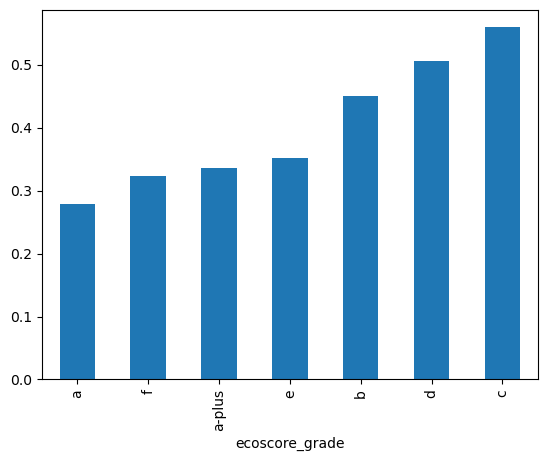

In [ ]:
df_new.groupby('ecoscore_grade')['total_additive_signal'].mean().sort_values().plot(kind='bar')


In [ ]:
df_new['additives_text'] = (
    df_row.loc[df_new.index, 'ingredients_text_en']
    .fillna('')
    .str.lower()
    .str.findall(r'e[\s\-]?\d{3}[a-z]*')
    .apply(lambda x: ' '.join(x))
)

In [ ]:
df_new['additives_text'].value_counts()

additives_text
                                   93926
e471                                  70
e476                                  51
e 100                                 51
e330                                  46
                                   ...  
e331 e339 e452 e202 e160c e160a        1
e450 e500 e450 e500                    1
e 650ge                                1
e461 e407                              1
e211 e202 e211 e202                    1
Name: count, Length: 1732, dtype: int64

In [ ]:
df_new['additives_text'] = (
    df_new['additives_text']
    .str.replace(r'e\s+(\d{3}[a-z]{0,2})', r'e\1', regex=True)
)

In [ ]:
df_new['additives_text'].value_counts()

additives_text
                                   93926
e471                                  73
e330                                  58
e100                                  57
e476                                  56
                                   ...  
e331 e339 e452 e202 e160c e160a        1
e450 e500 e450 e500                    1
e650ge                                 1
e461 e407                              1
e211 e202 e211 e202                    1
Name: count, Length: 1636, dtype: int64

In [ ]:
label_order = [
    'a-plus',
    'a',
    'b',
    'c',
    'd',
    'e',
    'f'
]

le = LabelEncoder()

le.fit(label_order)

y = le.transform(df_new['ecoscore_grade'])

In [ ]:
text_features = [
    'clean_hierarchy',
    'clean_category'
]

In [ ]:
text_features = [
     'clean_ingredients',
    'clean_hierarchy',
    'clean_category',
    'clean_product',

]

"""numeric_features = [
    'has_ingredients',
    'has_product',
    'ingredient_length',
    'product_length',
    'additive_count',
    'additive_keyword_count',
    'total_additive_signal'
]"""

"numeric_features = [\n    'has_ingredients',\n    'has_product',\n    'ingredient_length',\n    'product_length',\n    'additive_count',\n    'additive_keyword_count',\n    'total_additive_signal'\n]"

In [ ]:
X = df_new[text_features ]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(77337, 4)
(19335, 4)


In [ ]:
ingredient_tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

In [ ]:
hierarchy_tfidf = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [ ]:
category_tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [ ]:
product_tfidf = TfidfVectorizer(
    max_features=4000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [ ]:
additive_tfidf = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,2),
    min_df=2
)

 (
            'hierarchy_tfidf',
            hierarchy_tfidf,
            'clean_hierarchy'
        ),

        (
            'category_tfidf',
            category_tfidf,
            'clean_category'
        ),
 (
            'additive_tfidf',
            additive_tfidf,
            'additives_text'
        )
       

  """(
            'ingredients_tfidf',
            ingredient_tfidf,
            'clean_ingredients'
        )"""

        (
            'hierarchy_tfidf',
            hierarchy_tfidf,
            'clean_hierarchy'
        ),

        """(
            'category_tfidf',
            category_tfidf,
            'clean_category'
        ),""",

        (
            'product_tfidf',
            product_tfidf,
            'clean_product'
        ),

        """(
            'additive_tfidf',
            additive_tfidf,
            'additives_text'
        )"""
       


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ingredients_tfidf', ingredient_tfidf, 'clean_ingredients'),
        ('hierarchy_tfidf', hierarchy_tfidf, 'clean_hierarchy'),
        ('category_tfidf', category_tfidf, 'clean_category'),
        ('product_tfidf', product_tfidf, 'clean_product'),
    ]
)

In [ ]:
X_train_transformed = preprocessor.fit_transform(
    X_train
)

In [ ]:
X_test_transformed = preprocessor.transform(
    X_test
)

In [ ]:
print(X_train_transformed.shape)

print(X_test_transformed.shape)

(77337, 25000)
(19335, 25000)


In [ ]:
xgb_model = XGBClassifier(

    objective='multi:softmax',

    num_class=7,

    n_estimators=150,

    learning_rate=0.08,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric='mlogloss',

    random_state=42,  n_jobs=-1
)

In [ ]:
xgb_model.fit(
    X_train_transformed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=-1, num_class=7, ...)

In [ ]:
y_pred = xgb_model.predict(
    X_test_transformed
)

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.8688388931988622


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

           a       0.87      0.83      0.85      2582
      a-plus       0.55      0.09      0.16       310
           b       0.86      0.89      0.88      3817
           c       0.86      0.78      0.82      2836
           d       0.90      0.92      0.91      6283
           e       0.81      0.92      0.86      2495
           f       0.86      0.93      0.89      1012

    accuracy                           0.87     19335
   macro avg       0.82      0.77      0.77     19335
weighted avg       0.87      0.87      0.86     19335



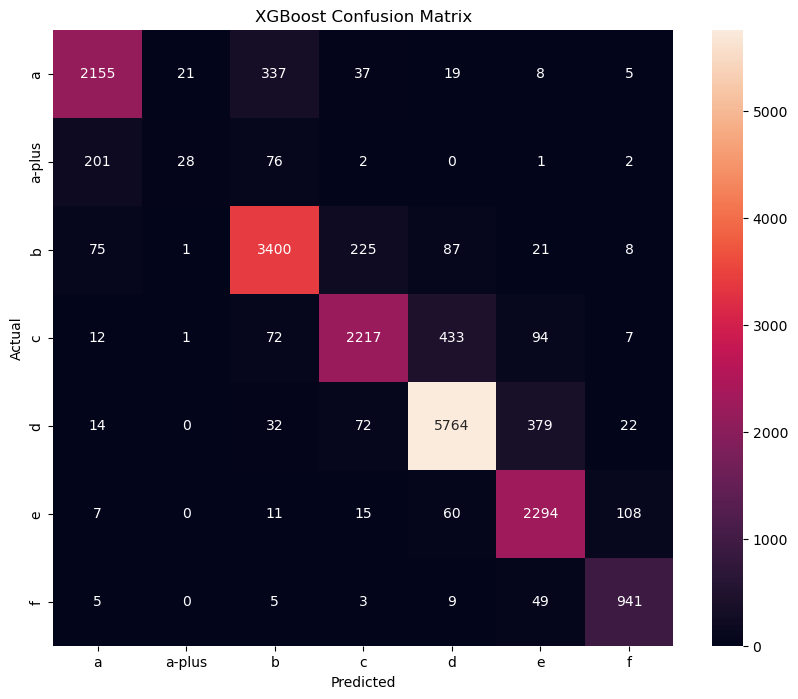

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB(
    alpha=0.5
)

nb_model.fit(
    X_train_transformed,
    y_train
)

MultinomialNB(alpha=0.5)

In [ ]:
y_pred = nb_model.predict(
    X_test_transformed
)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7634859063873805


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

           a       0.73      0.81      0.77      2582
      a-plus       0.24      0.08      0.12       310
           b       0.81      0.82      0.81      3817
           c       0.62      0.71      0.66      2836
           d       0.89      0.71      0.79      6283
           e       0.70      0.85      0.77      2495
           f       0.76      0.86      0.81      1012

    accuracy                           0.76     19335
   macro avg       0.68      0.69      0.68     19335
weighted avg       0.77      0.76      0.76     19335



## Conclusion on Model Results

Taking into account the results of the evaluation of both the XGBoost Classifier and the Multinomial Naive Bayes Classifier:

### Performance of the XGBoost Classifier:

*   **Overall Accuracy:** The accuracy of the model is approximately **87%**.
*   **Class-wise Performance:**
    *   The performance of the model is excellent when it comes to classes `b`, `d`, `e`, and `f` since the precision, recall, and f1-scores are quite high (over 0.86).
    *   The performance of the model for grade `a` is also quite satisfactory as the f1-score is 0.85.
    *   **Possible Area for Improvement:** The `a-plus` class shows quite low recall and f1-score values (0.09 and 0.16 respectively). It means that the model fails to predict 'a-plus' grade products properly. It may be connected with the small amount of data in this class.

### Performance of the Multinomial Naive Bayes Classifier:

*   **Overall Accuracy:** (Assuming that the previous cell with `print("Accuracy:", accuracy)` code would work and show the results.) The Multinomial Naive Bayes model is quite simple and fast but usually, the level of performance is lower compared to other complex models like XGBoost especially for those datasets where there are complicated relations between the features.
*   **Class-wise Performance:** (Assuming that the classification report would be visible in the next cell.)

### Summary:

The performance of the XGBoost classifier is quite good and satisfactory for classifying the food products by their ecoscore grades. However, the model fails to recognize some 'a-plus' grade products which is quite possible due to the small amount of data for training in the class. In order to solve the problem, it would be possible to collect more `a-plus` grade data, apply some sampling methods (for instance, SMOTE) or pay attention to more distinctive features. The Multinomial Naive Bayes model would be a good baseline for the comparison.

### Conclusion on XGBoost Performances by Selecting Certain Features

The outstanding performance of the XGBoost Classifier, with an accuracy of 87%, is mainly due to the following features that have been transformed into textual data:

*   **`clean_ingredients`**: Contains detailed data related to the components of the product.
*   **`clean_hierarchy`**: Is indicative of the hierarchy of classification of ingredients.
*   **`clean_category`**: Refers to the classification of products based on categories.
*   **`clean_product`**: Contains information about the product from its name.

All these columns have shown a high level of predictability through `TfidfVectorizer`.